# Tahim Bhuiya

# Statistical Inference & Linear Regression

## Hypotheses:

### A. Two hypotheses for a t-test:
1.
   
   * H0: There is NOT a significant difference in the number of delayed flights (arr_del15) for high-traffic and low-traffic airport month observations.
  
     
   *   Ha: There is a significant difference in the number of delayed flights (arr_del15) for high-traffic and low-traffic airport month observations.
2.
   
   * H0: There is NOT a significant difference in total arrival delay minutes (arr_delay) for high and low weather-delay observations.
  
   * Ha: There is a significant difference in total arrival delay minutes (arr_delay) for high and low weather-delay observations.

### B. Two hypotheses for a chi-square test:
1.
   
   * H0: There is NOT a significant association between airline (carrier_name) and delay category (high vs low number of delayed flights).
     
   * Ha: There is a significant association between airline (carrier_name) and delay category (high vs low number of delayed flights).
  
2.
   
   * H0: There is NOT a significant association between month and weather-delay category (high vs low weather-related delay counts based on weather_ct).
     
   * Ha: There is a significant association between month and weather-delay category (high vs low weather-related delay counts based on weather_ct).

### C. Two hypotheses for linear regression:
1.
* Dependent variable (numerical outcome variable): arr_del15 (number of arrival flights delayed by 15 minutes or more)
     
* Main independent variable: arr_flights (total number of arrival flights)

* Control variables: weather_ct, nas_ct, late_aircraft_ct

* H0: There is NOT a positive statistically significant relationship between the total number of arrival flights (arr_flights) and the number of arrival flights delayed by 15 minutes or more (arr_del15).
* H1: There is a positive statistically significant relationship between the total number of arrival flights (arr_flights) and the number of arrival flights delayed by 15 minutes or more (arr_del15).


2.
* Dependent variable (numerical outcome variable): arr_delay (total arrival delay minutes across all causes)

* Main independent variable: weather_ct (number of flights delayed due to weather)

* Control variables: carrier_ct, nas_ct, late_aircraft_ct

* H0: There is NOT a positive statistically significant relationship between the number of weather-related delayed flights (weather_ct) and total arrival delay minutes (arr_delay).
* H1: There is a positive statistically significant relationship between the number of weather-related delayed flights (weather_ct) and total arrival delay minutes (arr_delay).

In [1]:
import pandas as pd
df = pd.read_csv('Airline_Delay_Cause.csv')
df

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,...,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,...,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,...,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,...,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,...,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318012,2003,6,DL,Delta Air Lines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",480.0,84.0,25.69,3.09,...,0.0,21.26,0.0,0.0,3744.0,978.0,164.0,1023.0,0.0,1579.0
318013,2003,6,DL,Delta Air Lines Inc.,SFO,"San Francisco, CA: San Francisco International",505.0,111.0,21.78,2.24,...,0.0,13.17,3.0,0.0,4284.0,1376.0,138.0,2132.0,0.0,638.0
318014,2003,6,DL,Delta Air Lines Inc.,SJC,"San Jose, CA: Norman Y. Mineta San Jose Intern...",146.0,36.0,6.99,0.00,...,0.0,2.15,0.0,0.0,896.0,205.0,0.0,607.0,0.0,84.0
318015,2003,6,DL,Delta Air Lines Inc.,SJU,"San Juan, PR: Luis Munoz Marin International",95.0,13.0,3.66,0.00,...,0.0,1.42,0.0,0.0,367.0,120.0,0.0,210.0,0.0,37.0


In [2]:
df.columns # print the columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [3]:
df.shape # print the number of rows and columns

(318017, 21)

In [4]:
df = df.dropna() # remove rows containing nan values

In [5]:
df = df.drop_duplicates(keep='first') # drop duplicated rows, keep the firsdt occurance

In [6]:
df.shape

(317261, 21)

## Hypothesis Testing for t-tests - Part 1

####    *    H0: There is NOT a significant difference in the number of delayed flights (arr_del15) for high-traffic and low-traffic airport observations.
  
     
   #### *   Ha: There is a significant difference in the number of delayed flights (arr_del15) for high-traffic and low-traffic airport observations.

In [7]:
df.columns # print the columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

### Check whether the numerical variables follow normal distribution

<Axes: xlabel='arr_del15', ylabel='Count'>

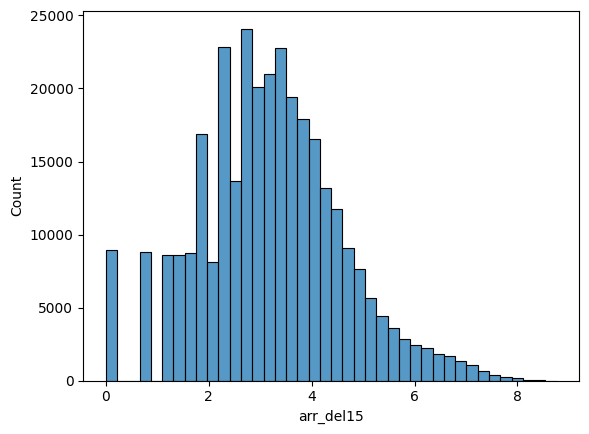

In [8]:
import seaborn as sns
import numpy as np

# Plot histogram of arr_del15
sns.histplot(data=df, x=np.log1p(df["arr_del15"]), bins=40)

The distribution of arr_del15 is right-skewed. T-Tests assume that there would be a normal distribution so this may not be the best test to use but we will still try it out and also utilize mannwhitneyu test.

In [9]:
import numpy as np

# Storing binary categories here for high/low traffic

# Step 1: Define the threshold
traffic_threshold = df['arr_flights'].median()

# Step 2: Separate the groups
high_traffic = df[df['arr_flights'] > traffic_threshold]['arr_del15']
low_traffic  = df[df['arr_flights'] <= traffic_threshold]['arr_del15']

### Perform the t-test

In [10]:
from scipy.stats import ttest_ind

ttest_ind(high_traffic, low_traffic)

TtestResult(statistic=183.63885219245734, pvalue=0.0, df=317259.0)

In [11]:
from scipy.stats import mannwhitneyu

mannwhitneyu(high_traffic, low_traffic)

MannwhitneyuResult(statistic=23884099258.0, pvalue=0.0)

The t-test and MannWhitneyU test both show p < 0.05, so this means that we can reject the null hypothesis which is that 'There is NOT a significant difference in the number of delayed flights (arr_del15) for high-traffic and low-traffic airport–month observations.' 

This means there is enough evidence to say that there is a significant difference in the number of delayed flights (arr_del15) between high-traffic and low-traffic airport–month observations.

## Hypothesis Testing for t-tests - Part 2

####    *       H0: There is NOT a significant difference in total arrival delay minutes (arr_delay) for high and low weather-delay observations.
  
  
  
     
   #### *     Ha: There is a significant difference in total arrival delay minutes (arr_delay) for high and low weather-delay observations.

### Check whether the numerical variables follow normal distribution

<Axes: xlabel='arr_delay', ylabel='Count'>

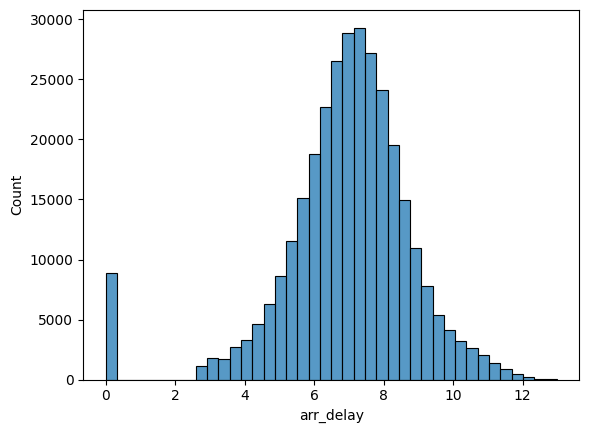

In [12]:
import seaborn as sns
import numpy as np

# Plot histogram of arr_delay
sns.histplot(data=df, x=np.log1p(df["arr_delay"]), bins=40)

The distribution here appears to be much more normal espeically compared to the previous example, but we see there is a bar going up on the left side of the plot that throws off this 'normal' distribution a bit, and the plot seems to be shifted to the right a bit which also throws this off from a perfect normal distribution that we would want. We will still try the t-test for this and see what we get and also try mannwhitneyu.

In [13]:
import numpy as np
# Storing binary categories here for high/low weather delay observations

# Step 1: Define the threshold
weather_threshold = df['weather_ct'].median()

# Step 2: Separate the groups
high_weather = df[df['weather_ct'] > weather_threshold]['arr_delay']
low_weather  = df[df['weather_ct'] <= weather_threshold]['arr_delay']

### Perform the t-test

In [14]:
from scipy.stats import ttest_ind

ttest_ind(high_weather, low_weather)

TtestResult(statistic=144.95042454126022, pvalue=0.0, df=317259.0)

In [15]:
from scipy.stats import mannwhitneyu

# Step 4: Run Mann-Whitney U test
mannwhitneyu(high_weather, low_weather)

MannwhitneyuResult(statistic=20464490357.0, pvalue=0.0)

The t-test and Mann–Whitney U test both show p < 0.05, so this means that we can reject the null hypothesis, which is that “There is NOT a significant difference in total arrival delay minutes (arr_delay) for high and low weather-delay observations.”

This means there is enough evidence to say that there is a significant difference in total arrival delay minutes (arr_delay) between high and low weather-delay observations.

## Hypothesis Testing for Chi-Squares - Part 1

####    *      H0: There is NOT a significant association between airline (carrier_name) and delay category (high vs low number of delayed flights).
#### *   Ha: There is a significant association between airline (carrier_name) and delay category (high vs low number of delayed flights).

### Create a contingency table

In [16]:
import pandas as pd

# Step 1: Create high/low delay category based on median of arr_del15
delay_threshold = df['arr_del15'].median()
df['delay_category'] = df['arr_del15'] > delay_threshold  # True = High delay, False = Low delay

# Step 2: Create crosstab of carrier_name vs delay_category
observations = pd.crosstab(index=df["carrier_name"], columns=df["delay_category"], margins=True)
observations

delay_category,False,True,All
carrier_name,,,
ATA Airlines d/b/a ATA,478,440,918
AirTran Airways Corporation,2630,4325,6955
Alaska Airlines Inc.,8614,4319,12933
Allegiant Air,5484,885,6369
Aloha Airlines Inc.,159,94,253
America West Airlines Inc.,668,911,1579
American Airlines Inc.,6357,13413,19770
American Eagle Airlines Inc.,5644,9755,15399
Atlantic Coast Airlines,512,741,1253


### Perform a chi-square test of independence

In [17]:
from scipy.stats import chi2_contingency

chi2, p, dof, ex = chi2_contingency(observations)

print("chi2 = ", chi2)
print("p = ", p)
print("degrees of freedom = ", dof)
print("expected = ", ex)

chi2 =  34343.79744488301
p =  0.0
degrees of freedom =  66
expected =  [[4.70280375e+02 4.47719625e+02 9.18000000e+02]
 [3.56296297e+03 3.39203703e+03 6.95500000e+03]
 [6.62542057e+03 6.30757943e+03 1.29330000e+04]
 [3.26276221e+03 3.10623779e+03 6.36900000e+03]
 [1.29608861e+02 1.23391139e+02 2.53000000e+02]
 [8.08902736e+02 7.70097264e+02 1.57900000e+03]
 [1.01279336e+04 9.64206644e+03 1.97700000e+04]
 [7.88872276e+03 7.51027724e+03 1.53990000e+04]
 [6.41896851e+02 6.11103149e+02 1.25300000e+03]
 [6.22839738e+03 5.92960262e+03 1.21580000e+04]
 [3.93693320e+03 3.74806680e+03 7.68500000e+03]
 [3.53888544e+03 3.36911456e+03 6.90800000e+03]
 [1.40971409e+04 1.34208591e+04 2.75180000e+04]
 [2.82219454e+03 2.68680546e+03 5.50900000e+03]
 [4.59983386e+03 4.37916614e+03 8.97900000e+03]
 [1.25443960e+04 1.19426040e+04 2.44870000e+04]
 [7.26936658e+02 6.92063342e+02 1.41900000e+03]
 [6.28833508e+03 5.98666492e+03 1.22750000e+04]
 [1.83347872e+03 1.74552128e+03 3.57900000e+03]
 [4.29297336e+02

### Interpreting the results considering the p-value and in terms of H0 and H1

The chi-square test shows p < 0.05, so we can reject the null hypothesis, which is that “There is NOT a significant association between airline (carrier_name) and delay category (high vs low number of delayed flights).”

This means there is enough evidence to say that there is a significant association between airline (carrier_name) and whether an observation has a high or low number of delayed flights (arr_del15).

## Hypothesis Testing for Chi-Squares - Part 2

#### * H0: There is NOT a significant association between month and weather-delay category (high vs low weather-related delay counts based on weather_ct).    
#### * Ha: There is a significant association between month and weather-delay category (high vs low weather-related delay counts based on weather_ct).

### Create a contingency table

In [18]:
import pandas as pd

# Step 1: Create high/low weather-delay category based on median of weather_ct
weather_threshold = df['weather_ct'].median()
df['weather_category'] = df['weather_ct'] > weather_threshold  # True = High weather delay, False = Low

# Step 2: Create crosstab of month vs weather_category
observations_weather = pd.crosstab(index=df["month"], columns=df["weather_category"], margins=True)
observations_weather

weather_category,False,True,All
month,,,
1,12745,14107,26852
2,12756,13568,26324
3,14067,12424,26491
4,14541,11978,26519
5,12929,13273,26202
6,10686,15582,26268
7,10091,15958,26049
8,11214,15351,26565
9,15268,11362,26630


### Perform a chi-square test of independence

In [19]:
from scipy.stats import chi2_contingency

chi2, p, dof, ex = chi2_contingency(observations_weather)

print("chi2 = ", chi2)
print("p = ", p)
print("degrees of freedom = ", dof)
print("expected = ", ex)

chi2 =  6536.805816686998
p =  0.0
degrees of freedom =  24
expected =  [[ 13433.57500607  13418.42499393  26852.        ]
 [ 13169.42605615  13154.57394385  26324.        ]
 [ 13252.9731672   13238.0268328   26491.        ]
 [ 13266.98106606  13252.01893394  26519.        ]
 [ 13108.39163969  13093.60836031  26202.        ]
 [ 13141.41025843  13126.58974157  26268.        ]
 [ 13031.84847807  13017.15152193  26049.        ]
 [ 13289.99404276  13275.00595724  26565.        ]
 [ 13322.5123794   13307.4876206   26630.        ]
 [ 13132.90546269  13118.09453731  26251.        ]
 [ 13192.93931495  13178.06068505  26371.        ]
 [ 13377.04312853  13361.95687147  26739.        ]
 [158720.         158541.         317261.        ]]


### Interpreting the results considering the p-value and in terms of H0 and H1

The chi-square test shows p < 0.05, so we can reject the null hypothesis, which is that “There is NOT a significant association between month and weather-delay category (high vs low weather-related delay counts based on weather_ct).”

This means there is enough evidence to say that there is a significant association between the month of the year and whether an observation has a high or low number of weather-related delays.

## Hypothesis Testing for Linear Regression - Part 1

### Below are:
* Dependent variable based on the hypothesis.
  
* The main independent variable based on the hypothesis.
  
* Control variables

* Dependent variable (numerical outcome variable): arr_del15 (number of arrival flights delayed by 15 minutes or more)
     
* Main independent variable: arr_flights (total number of arrival flights)

* Control variables: weather_ct (Count of flights delayed because of significant weather conditions), nas_ct (Count of flights delayed due to National Airspace System issues), and late_aircraft_ct (Count of flights delayed because the aircraft arrived late from a previous flight.)

* H0: There is NOT a positive statistically significant relationship between the total number of arrival flights (arr_flights) and the number of arrival flights delayed by 15 minutes or more (arr_del15).
* H1: There is a positive statistically significant relationship between the total number of arrival flights (arr_flights) and the number of arrival flights delayed by 15 minutes or more (arr_del15).

### Creating a scatterplot by using the dependent and the independent variable

NameError: name 'plt' is not defined

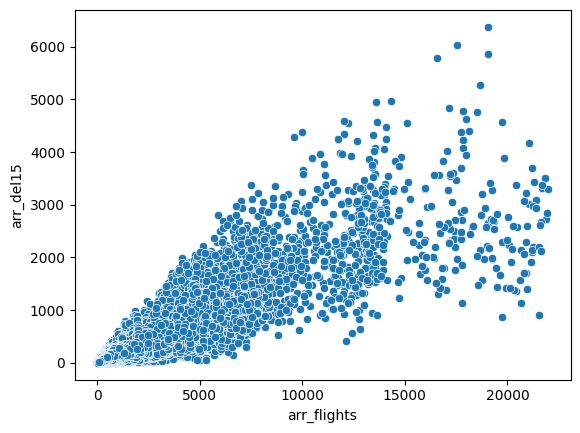

In [20]:
import matplotlib as plt
sns.scatterplot(data=df, x='arr_flights', y='arr_del15')
plt.xlabel('Total Arrival Flights (arr_flights)')
plt.ylabel('Number of Delayed Flights (arr_del15)')
plt.title('Scatterplot of arr_flights vs arr_del15')
plt.show()